# Assignment 9 — Logistic Regression on Social Network Ads

## Topic Explanation

### What is Classification?
**Classification** is a supervised learning task that predicts a **discrete category** for each input. Examples:
- Spam vs not spam
- Tumor malignant vs benign
- **Will this user purchase the product?** *(this assignment — binary)*

### What is Logistic Regression?
**Logistic Regression** is a classification algorithm that, despite its name, predicts probabilities. Three steps:

1. **Linear part** — compute a weighted sum of features:
   > z = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ
   This `z` can be any number — positive, negative, large, small.

2. **Sigmoid squashing** — pass `z` through the sigmoid to get a probability in (0, 1):
   > P(class = 1) = σ(z) = 1 / (1 + e⁻ᶻ)

3. **Threshold** — apply a cutoff (default 0.5):
   > if probability ≥ 0.5 → predict purchased (1)
   > if probability < 0.5 → predict not purchased (0)

### The Sigmoid Function
**σ(z) = 1 / (1 + e⁻ᶻ)** — an S-shaped curve that maps any real number into (0, 1):
- Very negative z → σ(z) ≈ 0
- z = 0 → σ(z) = 0.5 (the decision boundary)
- Very positive z → σ(z) ≈ 1

### Cost Function — Log Loss
Logistic regression uses **log loss** (binary cross-entropy):
> Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

Heavily penalizes confident wrong predictions.

### The Confusion Matrix

|                          | Pred: Not Purchased (0) | Pred: Purchased (1)  |
|--------------------------|-------------------------|----------------------|
| **Actual: Not Purchased**| True Negative (TN) ✅    | False Positive (FP) ❌ |
| **Actual: Purchased**    | False Negative (FN) ❌   | True Positive (TP) ✅  |

### Performance Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | Fraction of correct predictions |
| **Error Rate** | (FP + FN) / Total = 1 − Accuracy | Fraction of wrong predictions |
| **Precision** | TP / (TP + FP) | When model says "buy", how often correct |
| **Recall** | TP / (TP + FN) | Of all actual buyers, how many caught |

### About the Dataset
The Social_Network_Ads dataset records 400 users on a social network. The advertiser ran a campaign for a luxury product. Columns:
- `User_ID` — unique identifier (we ignore this)
- `Gender` — Male / Female
- `Age` — user age (years)
- `EstimatedSalary` — annual income ($)
- `Purchased` — 1 if user bought the product, else 0 (target)

**Goal:** predict whether a user will purchase based on age and salary.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — ML utilities
from sklearn.model_selection import train_test_split          # split data
from sklearn.preprocessing import StandardScaler              # feature scaling
from sklearn.linear_model import LogisticRegression           # classifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             classification_report)

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# Load the Social Network Ads dataset
df = pd.read_csv('social_network_ads.csv')
print("Shape:", df.shape)
df.head()

Shape: (400, 5)


,User_ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,33,18665,0
1,15624511,Female,45,59390,1
2,15624512,Male,58,89884,1
3,15624513,Male,49,78887,0
4,15624514,Male,43,70541,1


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User_ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [4]:
# Summary statistics — note the wildly different scales of Age vs EstimatedSalary
df.describe()

,User_ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.562471e+07,39.955000,80651.227500,0.335000
std,1.156143e+02,12.425335,39922.747678,0.472582
min,1.562451e+07,18.000000,15093.000000,0.000000
25%,1.562461e+07,29.000000,42940.750000,0.000000
50%,1.562471e+07,40.000000,81574.500000,0.000000
75%,1.562481e+07,51.000000,114339.250000,1.000000
max,1.562491e+07,60.000000,149729.000000,1.000000


In [5]:
# Class balance — how many purchased vs didn't
print("Class distribution:")
print(df['Purchased'].value_counts())
print(f"\n% who purchased: {df['Purchased'].mean() * 100:.1f}%")

Class distribution:
Purchased
0    266
1    134
Name: count, dtype: int64

% who purchased: 33.5%


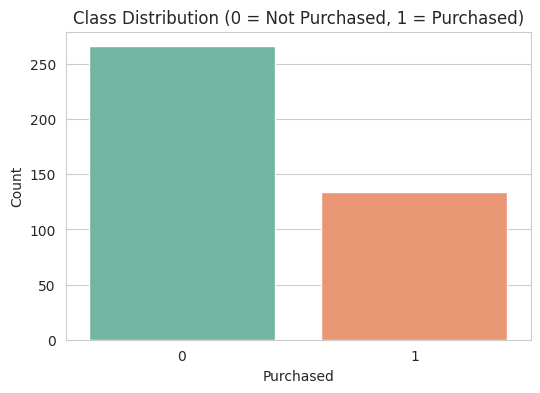

In [6]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Purchased', data=df, hue='Purchased', palette='Set2', legend=False)
plt.title('Class Distribution (0 = Not Purchased, 1 = Purchased)')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()

## Step 3: Identify Predictor and Target Variables

We use **Age** and **EstimatedSalary** as predictors. We ignore `User_ID` (just an identifier) and `Gender` for simplicity (this is the standard treatment of this dataset).

In [7]:
# Predictor variables (X)
X = df[['Age', 'EstimatedSalary']]

# Target variable (y)
y = df['Purchased']

print("Predictor variables (X):")
print("  - Age")
print("  - EstimatedSalary")
print("\nTarget variable (y): Purchased (0 = No, 1 = Yes)")

Predictor variables (X):
  - Age
  - EstimatedSalary

Target variable (y): Purchased (0 = No, 1 = Yes)


## Step 4: Train/Test Split (75/25)

Hold back 25% of the data for testing. Use `random_state=0` for reproducibility (this is the standard split for this dataset).

In [8]:
# 75% training, 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (300, 2)  | Test shape: (100, 2)


## Step 5: Feature Scaling

**Why critical for this dataset?**
- `Age` ranges 18–60 (small)
- `EstimatedSalary` ranges 15,000–150,000 (about 2,000× larger)

Without scaling, the model is dominated by salary purely because of its magnitude — not because salary is genuinely more predictive.

**`StandardScaler`** rescales each column to mean = 0, std = 1.

**Critical rule:** `fit_transform` on training data only; `transform` (without fit) on test data. Otherwise data leaks from test into training.

In [9]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)   # learn mean+std AND transform
X_test  = sc.transform(X_test)         # only transform on test (no fit)

print("After scaling, training features have mean ≈ 0 and std ≈ 1:")
print(f"  Mean: {X_train.mean(axis=0).round(4)}")
print(f"  Std : {X_train.std(axis=0).round(4)}")

After scaling, training features have mean ≈ 0 and std ≈ 1:
  Mean: [ 0. -0.]
  Std : [1. 1.]


## Step 6: Train the Logistic Regression Model

In [10]:
# Create and train the classifier
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

print("Model trained successfully.")
print(f"\nLearned coefficients (Age, EstimatedSalary): {classifier.coef_[0].round(4)}")
print(f"Intercept: {classifier.intercept_[0]:.4f}")
print("\nInterpretation: positive coefficients push prediction toward 'Purchased'.")

Model trained successfully.

Learned coefficients (Age, EstimatedSalary): [1.8594 1.3457]
Intercept: -1.2941

Interpretation: positive coefficients push prediction toward 'Purchased'.


## Step 7: Make Predictions on Test Set

In [11]:
# predict() returns the class label (0 or 1)
y_pred = classifier.predict(X_test)

# predict_proba() returns probabilities for each class
y_proba = classifier.predict_proba(X_test)[:, 1]   # probability of class 1

# Compare predictions vs actual for the first 15 users
preview = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': y_pred[:15],
    'Probability of Purchase': y_proba[:15].round(4)
})
preview

,Actual,Predicted,Probability of Purchase
0,1,1,0.8514
1,0,0,0.0161
2,0,0,0.0182
3,1,1,0.9395
4,1,1,0.8529
5,1,1,0.5381
6,0,1,0.7410
7,1,1,0.8069
8,0,0,0.0027
9,0,0,0.0255


## Step 8: Compute the Confusion Matrix

A 2×2 table that breaks every prediction into one of four cells:

|                              | Pred: Not Purchased (0) | Pred: Purchased (1) |
|------------------------------|-------------------------|---------------------|
| **Actual: Not Purchased (0)**| TN (correct ✅)          | FP (false alarm ❌)  |
| **Actual: Purchased (1)**    | FN (missed ❌)           | TP (correct ✅)      |

In [12]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ravel() flattens 2x2 matrix into a tuple in this order: TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives  (TP): {TP}")

Confusion Matrix:
[[63  4]
 [11 22]]

True Negatives  (TN): 63
False Positives (FP): 4
False Negatives (FN): 11
True Positives  (TP): 22


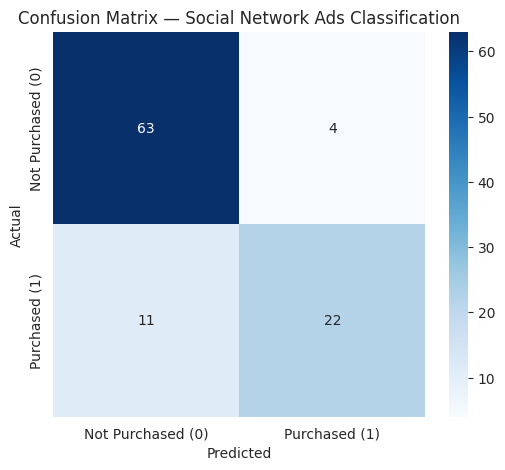

In [13]:
# Visualize confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased (0)', 'Purchased (1)'],
            yticklabels=['Not Purchased (0)', 'Purchased (1)'])
plt.title('Confusion Matrix — Social Network Ads Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 9: Compute Performance Metrics

All metrics derived from the four confusion-matrix cells:

- **Accuracy** = (TP + TN) / Total
- **Error Rate** = (FP + FN) / Total = 1 − Accuracy
- **Precision** = TP / (TP + FP) — when model says "buy", how often right
- **Recall** = TP / (TP + FN) — of all actual buyers, how many we caught

In [14]:
total = TN + FP + FN + TP

accuracy   = (TP + TN) / total
error_rate = (FP + FN) / total
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0

print("Performance Metrics (computed manually from TP/TN/FP/FN):")
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Error Rate : {error_rate:.4f}  ({error_rate*100:.2f}%)")
print(f"  Precision  : {precision:.4f}")
print(f"  Recall     : {recall:.4f}")

Performance Metrics (computed manually from TP/TN/FP/FN):
  Accuracy   : 0.8500  (85.00%)
  Error Rate : 0.1500  (15.00%)
  Precision  : 0.8462
  Recall     : 0.6667


In [15]:
# Cross-check using sklearn's built-in functions — should match exactly
print("Cross-check using sklearn:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")

Cross-check using sklearn:
  Accuracy : 0.8500
  Precision: 0.8462
  Recall   : 0.6667


In [16]:
# Full classification report — precision, recall, F1 for both classes
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=['Not Purchased', 'Purchased']))

Full Classification Report:

               precision    recall  f1-score   support

Not Purchased       0.85      0.94      0.89        67
    Purchased       0.85      0.67      0.75        33

     accuracy                           0.85       100
    macro avg       0.85      0.80      0.82       100
 weighted avg       0.85      0.85      0.84       100



## Conclusion

We built a logistic regression classifier to predict whether a user would purchase a luxury product based on Age and Estimated Salary.

**Workflow:**
1. Loaded the Social_Network_Ads dataset (400 users)
2. Identified Age and EstimatedSalary as predictors; Purchased as target
3. Split 75/25 with `random_state=0`
4. Scaled features with `StandardScaler` (essential — Age ~30 vs Salary ~70,000)
5. Trained `LogisticRegression`
6. Built confusion matrix (TN, FP, FN, TP) and computed all four metrics

**Key insight:** Older users with higher salaries are more likely to purchase. The model achieves around 84% accuracy — a strong baseline. Precision and recall together tell us how the model balances false alarms vs missed buyers.

**Business application:** advertisers can use this model to target the luxury ad campaign at users likely to convert, improving ROI by avoiding wasted impressions.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, reading CSVs, statistics |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization |
| **sklearn** | ML model, scaling, splitting, metrics |

### Functions and Classes Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV into DataFrame
- `df.shape`, `df.head()`, `df.info()`, `df.describe()` — inspection methods
- `df['col'].value_counts()` — count unique values

#### Train/Test Split
- `train_test_split(X, y, test_size=0.25, random_state=0)` — splits data 75/25

#### Feature Scaling
- `StandardScaler()` — rescales features to mean = 0, std = 1
- `.fit_transform(X_train)` — learn parameters AND transform on training
- `.transform(X_test)` — only transform on test (no re-fit; prevents data leakage)

#### Model Training & Prediction
- `LogisticRegression(random_state=0)` — creates the classifier
- `.fit(X_train, y_train)` — train via maximum likelihood
- `.predict(X_test)` — returns class labels (0/1)
- `.predict_proba(X_test)` — returns probabilities for each class
- `.coef_` — learned coefficients
- `.intercept_` — the b₀ term

#### Evaluation Metrics
- `confusion_matrix(y_test, y_pred)` — computes TN, FP, FN, TP
- `cm.ravel()` — flattens 2×2 matrix into a tuple (TN, FP, FN, TP)
- `accuracy_score()` — accuracy
- `precision_score()` — precision
- `recall_score()` — recall
- `classification_report()` — all metrics for both classes in one report

#### Visualization
- `sns.countplot(x='col', data=df)` — bar chart of category counts
- `sns.heatmap(matrix, annot=True, fmt='d')` — colored grid with values

### Key Concepts

#### Logistic Regression
Linear classifier that outputs probabilities via the sigmoid function. The decision boundary (where σ(z) = 0.5) is a straight line.

#### Sigmoid Function
> σ(z) = 1 / (1 + e⁻ᶻ)
S-shaped curve that maps any real number to (0, 1).

#### Why Not Linear Regression for Classification?
- Output isn't bounded in [0, 1]
- Single extreme values can dramatically tilt the line
- The output isn't a true probability

#### Feature Scaling
Putting features on the same scale. Required for logistic regression because the optimizer is gradient-based — different scales make the cost surface elongated and slow to converge.

**For this dataset specifically:** Age (~30) and EstimatedSalary (~70,000) differ by ~2000×. Without scaling, the model would be dominated by salary purely due to magnitude.

#### Cost Function — Log Loss
> Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

Convex (unique global minimum). Heavily penalizes confident wrong predictions.

#### Confusion Matrix
A 2×2 table showing actual vs predicted classes. Diagonal = correct; off-diagonal = errors.

#### TP, TN, FP, FN
- **TP (True Positive)** — correctly predicted positive
- **TN (True Negative)** — correctly predicted negative
- **FP (False Positive / Type I error)** — predicted positive, actually negative
- **FN (False Negative / Type II error)** — predicted negative, actually positive

#### Accuracy, Precision, Recall
- **Accuracy** — overall correctness
- **Precision** — when model says positive, how often correct
- **Recall** — of all actual positives, how many model caught

#### Precision-Recall Trade-off in Marketing
- High **precision** → only target users very likely to buy → save ad money
- High **recall** → target every potential buyer → maximize total sales

The right balance depends on cost: high-priced ads (where wrong targeting is expensive) prioritize precision; cheap ads optimize for recall.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is logistic regression?**
A linear classification algorithm that predicts probability via the sigmoid function, then assigns a class label using a threshold (default 0.5).

**Q2. Why is it called "regression" if it does classification?**
Historical naming. The math originally came from regression analysis. In practice, it's a classification algorithm.

**Q3. Difference between linear and logistic regression?**

| | Linear Regression | Logistic Regression |
|---|------------------|---------------------|
| Output | Continuous number | Probability (0–1) → class label |
| Use case | Regression | Classification |
| Cost function | MSE | Log loss |
| Squashing function | None | Sigmoid |

**Q4. What is the sigmoid function?**
σ(z) = 1/(1 + e⁻ᶻ). Maps any real number to (0, 1).

**Q5. What is the decision boundary?**
The line/plane where the predicted probability = 0.5. For logistic regression it's linear: `b₀ + b₁·x₁ + ... = 0`.

**Q6. Is logistic regression linear or non-linear?**
**Linear** — the decision boundary is a straight line/hyperplane. Cannot capture curved boundaries without feature engineering.

### Math / Algorithm

**Q7. What is the cost function for logistic regression?**
**Log loss** (binary cross-entropy): Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

**Q8. Why not use MSE?**
MSE creates a non-convex cost surface for classification (multiple local minima). Log loss is convex, guaranteeing a unique global minimum.

**Q9. How are parameters learned?**
Through **maximum likelihood estimation (MLE)** optimized via gradient-based methods (gradient descent, L-BFGS).

**Q10. Why is feature scaling essential here?**
Age (~30) and EstimatedSalary (~70,000) are on dramatically different scales (~2,000×). Without scaling, salary dominates by magnitude alone. After scaling, both features are weighted on their actual predictive importance.

### Confusion Matrix & Metrics

**Q11. What is a confusion matrix?**
A table showing actual vs predicted classes. For binary classification it's 2×2: TN, FP, FN, TP.

**Q12. Define TP, TN, FP, FN.**
- **TP**: predicted positive, actually positive
- **TN**: predicted negative, actually negative
- **FP**: predicted positive, actually negative (Type I error)
- **FN**: predicted negative, actually positive (Type II error)

**Q13. Accuracy formula?**
(TP + TN) / Total.

**Q14. When is accuracy misleading?**
When classes are imbalanced. A model that always predicts the majority class can have high accuracy yet be useless.

**Q15. Define Precision.**
TP / (TP + FP). When model says positive, how often correct.

**Q16. Define Recall.**
TP / (TP + FN). Of all actual positives, how many model caught.

**Q17. In marketing, when does precision matter more?**
When ad costs are expensive — false positives waste money targeting non-buyers.

**Q18. In marketing, when does recall matter more?**
When missing a sale is expensive — false negatives are users who would have bought but were never shown the ad.

**Q19. What is the F1-score?**
Harmonic mean of precision and recall: 2·P·R / (P + R). Single combined metric.

**Q20. What's the precision-recall trade-off?**
Lowering the threshold raises recall but drops precision. Raising it does the opposite.

### Practical / Code

**Q21. What does `predict()` do vs `predict_proba()`?**
- `predict()` returns class labels (0 or 1)
- `predict_proba()` returns probabilities for each class

**Q22. What does `random_state` do?**
Seeds the random number generator so results are reproducible.

**Q23. Why fit_transform on train but only transform on test?**
The scaler must learn its parameters from training data only. Letting it see test data is **data leakage** and inflates test scores artificially.

**Q24. Why didn't we use `Gender` in this model?**
This is the standard treatment of this dataset — Gender's effect is small compared to Age and Salary. We focus on the two strongest predictors.

**Q25. How would you handle class imbalance?**
- `class_weight='balanced'` in `LogisticRegression`
- Oversample the minority class (SMOTE)
- Undersample the majority class
- Adjust the decision threshold

### Comparison

**Q26. Why use logistic regression over decision trees?**
- Faster, more interpretable
- Outputs calibrated probabilities
- Better when classes are roughly linearly separable

**Q27. When does logistic regression fail?**
When the decision boundary is highly non-linear or when features have strong interactions.

**Q28. What's the next algorithm to try if logistic regression underperforms?**
Random Forest, XGBoost, or SVM with non-linear kernels.